# MSBA 265 - Foundational Module 1: Exploratory Data Analysis & Visual Outlier Audits

**Author:** Visiting Instructor Shyla Solis  
**Course:** MSBA 265 - Business Analytics Topics  
**Dataset:** French Motor Third Party Liability Claims (OpenML ID: 41214)

---

### Business Problem Overview

In property and casualty insurance, policy pricing depends on understanding risk exposure, driver age, and population density. Before building predictive loss models or business strategy dashboards, we must inspect raw feature data types, construct a domain-specific Business Data Dictionary, plot feature distributions, evaluate univariate skewness, and visually diagnose extreme outliers.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for clean presentation graphics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

# Load dataset
data_path = os.path.join("..", "data", "raw_business_data.csv")

if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw_business_data.csv")

df = pd.read_csv(data_path)

print(
    f"[+] Loaded Dataset Shape: "
    f"{df.shape[0]:,} rows x {df.shape[1]} columns"
)

df.head(10)

ModuleNotFoundError: No module named 'seaborn'

In [2]:
import sys
print(sys.executable)

C:\Users\87107\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe


In [1]:
import sys
print(sys.executable)

c:\Users\87107\msba265_module1\venv\Scripts\python.exe


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 20)

data_path = os.path.join("..", "data", "raw_business_data.csv")

if not os.path.exists(data_path):
    data_path = os.path.join("data", "raw_business_data.csv")

df = pd.read_csv(data_path)

print(
    f"[+] Loaded Dataset Shape: "
    f"{df.shape[0]:,} rows x {df.shape[1]} columns"
)

df.head(10)

[+] Loaded Dataset Shape: 678,013 rows x 12 columns


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,'D',5,0,55,50,'B12','Regular',1217,'R82'
1,3.0,1,0.77,'D',5,0,55,50,'B12','Regular',1217,'R82'
2,5.0,1,0.75,'B',6,2,52,50,'B12','Diesel',54,'R22'
3,10.0,1,0.09,'B',7,0,46,50,'B12','Diesel',76,'R72'
4,11.0,1,0.84,'B',7,0,46,50,'B12','Diesel',76,'R72'
5,13.0,1,0.52,'E',6,2,38,50,'B12','Regular',3003,'R31'
6,15.0,1,0.45,'E',6,2,38,50,'B12','Regular',3003,'R31'
7,17.0,1,0.27,'C',7,0,33,68,'B12','Diesel',137,'R91'
8,18.0,1,0.71,'C',7,0,33,68,'B12','Diesel',137,'R91'
9,21.0,1,0.15,'B',7,0,41,50,'B12','Diesel',60,'R52'


In [4]:
vehage_data = df[["VehAge"]]
display(vehage_data.head(10))

,VehAge
0,0
1,0
2,2
3,0
4,0
5,2
6,2
7,0
8,0
9,0


In [ ]:
print("==================================================")
print("1. STRUCTURAL DATA TYPES & NULLS")
print("==================================================")
df.info()

print("\n==================================================")
print("2. SUMMARY STATISTICS (NUMERICAL)")
print("==================================================")
df.describe().T

1. STRUCTURAL DATA TYPES & NULLS
<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  str    
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  str    
 9   VehGas      678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 62.1 MB

2. SUMMARY STATISTICS (NUMERICAL)


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [5]:
df["VehAge"].describe()

count    678013.000000
mean          7.044265
std           5.666232
min           0.000000
25%           2.000000
50%           6.000000
75%          11.000000
max         100.000000
Name: VehAge, dtype: float64

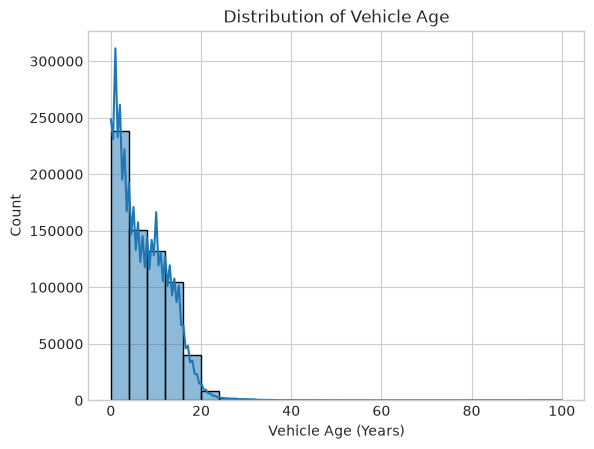

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["VehAge"], bins=25, kde=True)

plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Count")

plt.show()

In [ ]:
business_definitions = {
    "IDpol": (
        "Policy ID",
        "Key ID",
        "Unique policy identification key assigned to contract."
    ),
    "ClaimNb": (
        "Claim Count",
        "Count",
        "Total insurance claims filed during policy coverage period."
    ),
    "Exposure": (
        "Risk Exposure",
        "Years (0.0-1.0)",
        "Fraction of year policy was active (e.g., 0.50 = 6 months coverage)."
    ),
    "Area": (
        "Area Risk Code",
        "Ordinal Category",
        "Geographic risk code of policyholder address (A = rural, F = urban)."
    ),
    "VehPower": (
        "Engine Power",
        "Tax HP",
        "Fiscal power rating category of vehicle engine."
    ),
    "VehAge": (
        "Vehicle Age",
        "Years",
        "Age of the insured vehicle in years."
    ),
    "DrivAge": (
        "Driver Age",
        "Years",
        "Age of the primary insured driver in years."
    ),
    "BonusMalus": (
        "Claim History Index",
        "Index Score (50-350)",
        "Regulatory driver risk score (<100: safe discount; >100: claim surcharge)."
    ),
    "VehBrand": (
        "Brand Class",
        "Category Code",
        "Anonymized vehicle manufacturer / brand classification code."
    ),
    "VehGas": (
        "Fuel Type",
        "Binary Class",
        "Engine fuel type used (Diesel vs. Regular / Gasoline)."
    ),
    "Density": (
        "Population Density",
        "People / km2",
        "Population density of policyholder's municipality."
    ),
    "Region": (
        "Administrative Region",
        "Region Code",
        "French administrative region code corresponding to residency location."
    )
}

dict_list = []

for col in df.columns:
    label, unit, definition = business_definitions.get(
        col,
        (col, "N/A", "No business definition provided.")
    )

    dict_list.append({
        "Feature Name": col,
        "Business Label": label,
        "Data Type": str(df[col].dtype),
        "Unit": unit,
        "Null Count": df[col].isnull().sum(),
        "Unique Values": df[col].nunique(),
        "Business Definition": definition
    })

dict_df = pd.DataFrame(dict_list)

display(dict_df)

reports_dir = os.path.join("..", "reports")
os.makedirs(reports_dir, exist_ok=True)

dict_path = os.path.join(reports_dir, "data_dictionary.csv")
dict_df.to_csv(dict_path, index=False)

print(f"\n[+] Successfully exported Business Data Dictionary artifact to: {dict_path}")

,Feature Name,Business Label,Data Type,Unit,Null Count,Unique Values,Business Definition
0,IDpol,Policy ID,float64,Key ID,0,678013,Unique policy identification key assigned to c...
1,ClaimNb,Claim Count,int64,Count,0,11,Total insurance claims filed during policy cov...
2,Exposure,Risk Exposure,float64,Years (0.0-1.0),0,181,"Fraction of year policy was active (e.g., 0.50..."
3,Area,Area Risk Code,str,Ordinal Category,0,6,Geographic risk code of policyholder address (...
4,VehPower,Engine Power,int64,Tax HP,0,12,Fiscal power rating category of vehicle engine.
5,VehAge,Vehicle Age,int64,Years,0,78,Age of the insured vehicle in years.
6,DrivAge,Driver Age,int64,Years,0,83,Age of the primary insured driver in years.
7,BonusMalus,Claim History Index,int64,Index Score (50-350),0,115,Regulatory driver risk score (<100: safe disco...
8,VehBrand,Brand Class,str,Category Code,0,11,Anonymized vehicle manufacturer / brand classi...
9,VehGas,Fuel Type,str,Binary Class,0,2,Engine fuel type used (Diesel vs. Regular / Ga...



[+] Successfully exported Business Data Dictionary artifact to: ..\reports\data_dictionary.csv


In [1]:
# My assigned feature: VehAge

vehage_data = df[["VehAge"]]

display(vehage_data.head(10))

NameError: name 'df' is not defined

In [5]:
print("==================================================")
print("UNIVARIATE SKEWNESS DIAGNOSTICS")
print("==================================================")

numeric_df = df.select_dtypes(include=[np.number])

skewness_series = numeric_df.skew().sort_values(ascending=False)

skew_summary = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness Coefficient": skewness_series.values,
    "Diagnosis": [
        "Extremely Right-Skewed" if s > 3.0
        else "Moderately Skewed" if abs(s) > 1.0
        else "Unskewed / Symmetric"
        for s in skewness_series.values
    ],
    "Action Required": [
        "Log / Box-Cox Transform" if abs(s) > 1.0
        else "Standard Scaler Sufficient"
        for s in skewness_series.values
    ]
})

display(skew_summary)

UNIVARIATE SKEWNESS DIAGNOSTICS


,Feature,Skewness Coefficient,Diagnosis,Action Required
0,ClaimNb,5.599613,Extremely Right-Skewed,Log / Box-Cox Transform
1,Density,4.651421,Extremely Right-Skewed,Log / Box-Cox Transform
2,BonusMalus,1.728934,Moderately Skewed,Log / Box-Cox Transform
3,VehPower,1.171344,Moderately Skewed,Log / Box-Cox Transform
4,VehAge,1.147989,Moderately Skewed,Log / Box-Cox Transform
5,DrivAge,0.435759,Unskewed / Symmetric,Standard Scaler Sufficient
6,IDpol,0.237890,Unskewed / Symmetric,Standard Scaler Sufficient
7,Exposure,0.085318,Unskewed / Symmetric,Standard Scaler Sufficient


In [2]:
# My assigned feature: VehAge

vehage_data = df[["VehAge"]]

display(vehage_data.head(10))

NameError: name 'df' is not defined

In [6]:
print("==================================================")
print("PEARSON MULTICOLLINEARITY AUDIT")
print("==================================================")

corr_matrix = numeric_df.corr().abs()

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper_tri.columns:
    high_corr_features = upper_tri.index[
        upper_tri[col] >= 0.85
    ].tolist()

    for feat in high_corr_features:
        val = upper_tri.loc[feat, col]

        high_corr_pairs.append({
            "Feature 1": feat,
            "Feature 2": col,
            "Pearson Correlation (|r|)": round(val, 4),
            "Status": "ACTION REQUIRED: Severe Multicollinearity"
        })

if high_corr_pairs:
    display(pd.DataFrame(high_corr_pairs))
else:
    print(
        "[+] No severe collinear feature pairs "
        "(|r| >= 0.85) detected across numerical metrics."
    )

PEARSON MULTICOLLINEARITY AUDIT
[+] No severe collinear feature pairs (|r| >= 0.85) detected across numerical metrics.


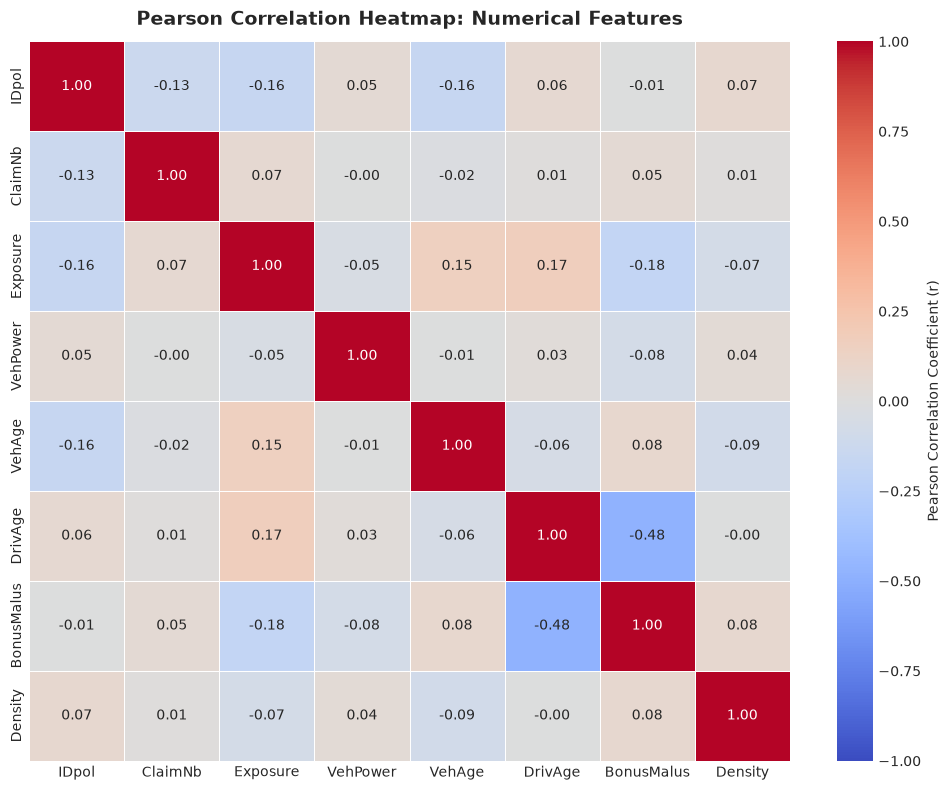

[+] Saved correlation heatmap graphics artifact to: ..\reports\figures\correlation_heatmap.png


In [7]:
# Cell 6b: Render Annotated Pearson Correlation Heatmap

plt.figure(figsize=(10, 8))

# Compute Pearson correlation matrix across numerical variables
corr = numeric_df.corr()

# Generate correlation heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"}
)

plt.title(
    "Pearson Correlation Heatmap: Numerical Features",
    fontsize=14,
    fontweight="bold",
    pad=12
)

plt.tight_layout()

heatmap_path = os.path.join(
    "..",
    "reports",
    "figures",
    "correlation_heatmap.png"
)

plt.savefig(heatmap_path, dpi=300)
plt.show()

print(
    f"[+] Saved correlation heatmap graphics artifact to: {heatmap_path}"
)

### Pearson Correlation Heatmap Interpretation

The Pearson correlation heatmap shows that most numerical features have weak linear relationships, and no feature pair reaches the severe multicollinearity threshold of |r| ≥ 0.85.

The strongest visible relationship is between **DrivAge** and **BonusMalus**, with a moderate negative correlation of approximately **r = -0.48**. This suggests that older drivers tend to have lower BonusMalus risk scores, which is consistent with experienced drivers accumulating safer driving histories and receiving larger discounts.

Most other correlations are relatively small. Therefore, no numerical feature needs to be removed solely because of severe Pearson multicollinearity.

However, Pearson correlation only evaluates numerical relationships. Domain knowledge must still be used to identify possible redundancy between categorical and numerical features such as **Area** and **Density**.

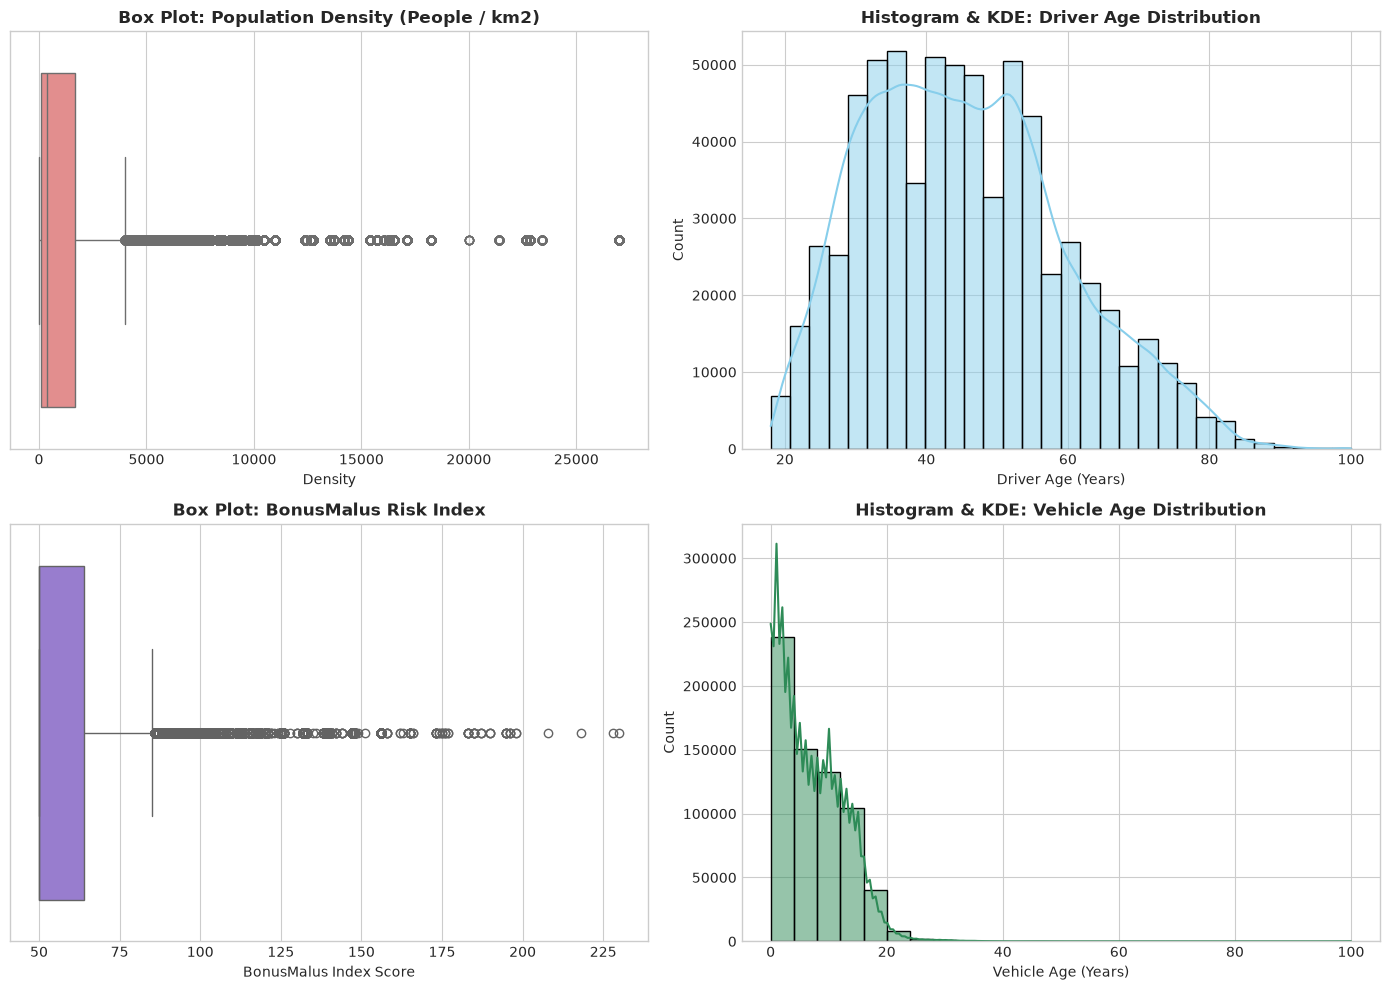

[+] Saved distribution graphics artifact to: ..\reports\figures\feature_distributions.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Population Density Box Plot
sns.boxplot(
    x=df["Density"],
    ax=axes[0, 0],
    color="lightcoral"
)
axes[0, 0].set_title(
    "Box Plot: Population Density (People / km2)",
    fontsize=12,
    fontweight="bold"
)
axes[0, 0].set_xlabel("Density")

# 2. Driver Age Histogram + KDE
sns.histplot(
    df["DrivAge"],
    kde=True,
    ax=axes[0, 1],
    color="skyblue",
    bins=30
)
axes[0, 1].set_title(
    "Histogram & KDE: Driver Age Distribution",
    fontsize=12,
    fontweight="bold"
)
axes[0, 1].set_xlabel("Driver Age (Years)")

# 3. BonusMalus Box Plot
sns.boxplot(
    x=df["BonusMalus"],
    ax=axes[1, 0],
    color="mediumpurple"
)
axes[1, 0].set_title(
    "Box Plot: BonusMalus Risk Index",
    fontsize=12,
    fontweight="bold"
)
axes[1, 0].set_xlabel("BonusMalus Index Score")

# 4. Vehicle Age Histogram + KDE
sns.histplot(
    df["VehAge"],
    kde=True,
    ax=axes[1, 1],
    color="seagreen",
    bins=25
)
axes[1, 1].set_title(
    "Histogram & KDE: Vehicle Age Distribution",
    fontsize=12,
    fontweight="bold"
)
axes[1, 1].set_xlabel("Vehicle Age (Years)")

plt.tight_layout()

fig_path = os.path.join(
    "..",
    "reports",
    "figures",
    "feature_distributions.png"
)

plt.savefig(fig_path, dpi=300)
plt.show()

print(
    f"[+] Saved distribution graphics artifact to: {fig_path}"
)

### Visual Distribution & Outlier Interpretation

#### 1. Population Density (Density)
The population density feature is extremely right-skewed, with most observations concentrated at relatively low density levels and a long right tail extending to approximately 27,000 people/km². Many observations appear beyond the upper box-plot whisker and are therefore statistical outliers.

However, these high-density observations may represent valid policyholders living in major urban areas rather than data-entry errors. Therefore, they should not be removed automatically. A log transformation such as `log(1 + Density)` may be more appropriate for downstream modeling.

#### 2. Driver Age (DrivAge)
Driver age shows a relatively stable, unimodal distribution concentrated around middle-aged drivers. The observed range is approximately 18 to 100 years, which remains within plausible legal and human boundaries.

There is no evidence of impossible values or severe outliers. No outlier removal is required, and standard scaling can be applied later if needed.

#### 3. BonusMalus Risk Index
BonusMalus is right-skewed. Most policyholders are concentrated around lower risk-score values, while a smaller group of high-risk drivers appears as individual points extending far beyond the upper whisker.

These high values are likely legitimate regulatory surcharge scores rather than data errors. Therefore, they should not automatically be removed. A useful feature-engineering step would be to create a binary indicator such as `BonusMalus > 100` to identify surcharge drivers.

#### 4. Vehicle Age (VehAge)
Vehicle age is strongly right-skewed. Most insured vehicles are relatively young, while a small number of much older vehicles create a long right tail.

Because older vehicles can still be valid observations, these values should first be interpreted using business context rather than automatically deleted. Transformation or robust modeling techniques may be considered if the skewness negatively affects downstream models.

=== OUTLIER AUDIT REPORT FOR 'Density' ===
Original Record Count: 678,013 records
Tukey IQR Range [-2257.00, 4007.00]: Excludes 77,566 records
Z-Score Threshold (|Z| <= 3.0): Excludes 15,209 records


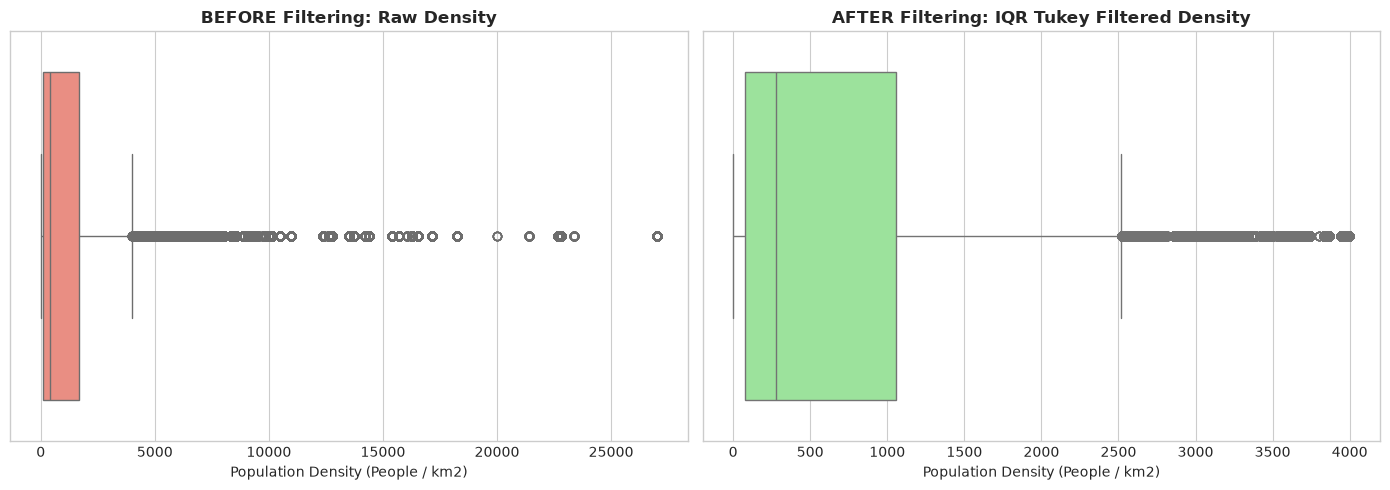

[+] Saved visual outlier comparison artifact to: ..\reports\figures\outlier_filtering_comparison.png


In [9]:
target_feature = "Density"

# Tukey IQR method
Q1 = df[target_feature].quantile(0.25)
Q3 = df[target_feature].quantile(0.75)
IQR = Q3 - Q1

iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR

df_iqr_cleaned = df[
    (df[target_feature] >= iqr_lower) &
    (df[target_feature] <= iqr_upper)
]

# Z-score method
z_scores = (
    df[target_feature] - df[target_feature].mean()
) / df[target_feature].std()

df_z_cleaned = df[abs(z_scores) <= 3.0]

# Report
print(f"=== OUTLIER AUDIT REPORT FOR '{target_feature}' ===")
print(f"Original Record Count: {len(df):,} records")

print(
    f"Tukey IQR Range [{iqr_lower:.2f}, {iqr_upper:.2f}]: "
    f"Excludes {len(df) - len(df_iqr_cleaned):,} records"
)

print(
    f"Z-Score Threshold (|Z| <= 3.0): "
    f"Excludes {len(df) - len(df_z_cleaned):,} records"
)

# Before / After visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x=df[target_feature],
    ax=axes[0],
    color="salmon"
)
axes[0].set_title(
    f"BEFORE Filtering: Raw {target_feature}",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_xlabel("Population Density (People / km2)")

sns.boxplot(
    x=df_iqr_cleaned[target_feature],
    ax=axes[1],
    color="lightgreen"
)
axes[1].set_title(
    f"AFTER Filtering: IQR Tukey Filtered {target_feature}",
    fontsize=12,
    fontweight="bold"
)
axes[1].set_xlabel("Population Density (People / km2)")

plt.tight_layout()

fig_filter_path = os.path.join(
    "..",
    "reports",
    "figures",
    "outlier_filtering_comparison.png"
)

plt.savefig(fig_filter_path, dpi=300)
plt.show()

print(
    f"[+] Saved visual outlier comparison artifact to: "
    f"{fig_filter_path}"
)

### Outlier Filtering Interpretation

The outlier audit evaluated population density (Density) across 678,013 policy records.

Using the non-parametric Tukey IQR method, the valid range was approximately -2,257 to 4,007 people/km². This method identified 77,566 records (about 11.44%) as statistical outliers.

In contrast, the parametric Z-score method (|Z| > 3.0) excluded only 15,209 records (about 2.24%). The large difference occurs because Density is strongly right-skewed. Extreme urban-density observations increase the mean and standard deviation, causing the Z-score threshold to become much less restrictive.

From a business perspective, many high-density observations likely represent legitimate urban policyholders rather than data-entry errors. Therefore, automatically deleting all Tukey outliers could remove a meaningful portion of the customer population and introduce selection bias.

If the business objective is statewide insurance pricing, it may be better to retain valid urban records and apply a transformation such as log(1 + Density). If the downstream model is highly sensitive to extreme leverage points, Tukey trimming may be considered.